In [149]:
import json
import sqlite3
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

In [2]:
def process_sqlite_report_kernel_only(filePath):
    con = sqlite3.connect(filePath)
    con.row_factory = sqlite3.Row 
    cur = con.cursor()
    query = """
    SELECT
        'kernel' AS activity_type,
        names.value AS name,
        k.start,
        k.end,
        k.end - k.start AS duration,
        k.registersPerThread,
        k.gridX, k.gridY, k.gridZ,
        k.blockX, k.blockY, k.blockZ,
        k.staticSharedMemory, k.dynamicSharedMemory,
        k.localMemoryPerThread, k.localMemoryTotal,
        k.sharedMemoryLimitConfig,
        k.streamId,
        k.deviceId,
        NULL AS bytes,
        NULL AS copyKind,
        NULL as srcKind,
        NULL as dstKind,
        NULL AS memKind          -- new column for memset
    FROM CUPTI_ACTIVITY_KIND_KERNEL AS k
    JOIN StringIds AS names ON k.demangledName = names.id
    
    ORDER BY start;
    """

    cur.execute(query)
    rows = [dict(row) for row in cur.fetchall()]
    return rows

In [3]:
data_matrix = process_sqlite_report_kernel_only("build/Linux-x86_64/pool_matching_joint_matrix_fp16.sqlite")

In [129]:
data_normal_fp16 = process_sqlite_report_kernel_only("build_normal/Linux-x86_64/pool_matching_normal_fp16.sqlite")

In [130]:
data_normal_fp32 = process_sqlite_report_kernel_only("build_normal_fp32/Linux-x86_64/pool_matching_normal_fp32.sqlite")

In [12]:
data_matrix[13]

{'activity_type': 'kernel',
 'name': 'Typeinfo name for popsift::Compute_squared_norm',
 'start': 730683475,
 'end': 730686323,
 'duration': 2848,
 'registersPerThread': 16,
 'gridX': 1000,
 'gridY': 1,
 'gridZ': 1,
 'blockX': 32,
 'blockY': 1,
 'blockZ': 1,
 'staticSharedMemory': 0,
 'dynamicSharedMemory': 0,
 'localMemoryPerThread': 0,
 'localMemoryTotal': 42467328,
 'sharedMemoryLimitConfig': 0,
 'streamId': 32,
 'deviceId': 0,
 'bytes': None,
 'copyKind': None,
 'srcKind': None,
 'dstKind': None,
 'memKind': None}

In [14]:
len(data_matrix)

8762

In [128]:
len(data_normal_fp16)

2496

In [13]:
def tensor_replace_names(data):
    pattern = r'\blambda\b'
    for row in data:
        match = re.search(pattern, row["name"])
        if match: 
            row["name"] = "remainder_normal_matching"
        if row["name"] == "Typeinfo name for popsift::Compute_distance_matrix_pre_norm":
            row["name"] = "matrix_matching"
        if row["name"] == "Typeinfo name for popsift::Compute_squared_norm":
            row["name"] = "compute_squared_norm"        

In [14]:
tensor_replace_names(data_matrix)

In [83]:
data_matrix[0]["start"]


723911182

In [87]:
data_matrix[2]["end"]

724382446

In [88]:
(data_matrix[2]["end"] - data_matrix[0]["start"]) / 1000000

0.471264

In [116]:
def tensor_match_time(data):
    start = 0
    # end = 0
    times: list[int] = []
    current_frame = False
    count = 0
    for index, row in enumerate(data):
        if row["name"] == "compute_squared_norm" and not current_frame:
            start = row["start"]
            current_frame = True
        else: 
            current_frame = False
            if index == len(data)- 1:
                count += 1
                if count > 4:
                    times.append(row["end"] - start)
            else:
                if data[index + 1]["name"] == "compute_squared_norm":
                    count += 1
                    if count > 4:
                        times.append(row["end"] - start)
    return times

519009

In [178]:
def normal_match_time(data):
    times: list[int] = []
    for row in data:
        times.append(row["duration"])
    return times

In [188]:
times_matrix =  tensor_match_time(data_matrix)
times_normal = normal_match_time(data_normal)

In [207]:
def diff(a, b): 
    """a - b (must be same lenght)"""
    diff_list = []
    for i in range(len(a)):
        diff_list.append(a[i] - b[i])
    return diff_list
    
def diff_percent(a, b): 
    """a - b (must be same lenght)"""
    diff_list = []
    for i in range(len(a)):
        diff_list.append(100 * (a[i] - b[i]) / b[i])
    return diff_list

In [202]:
times_normal[2499]

1779888591

In [203]:
times_matrix[2499]

87714868

In [204]:
times_normal[2499] - times_matrix[2499]

1692173723

In [208]:
diff_list = diff(times_normal, times_matrix)
diff_list_p = diff_percent(times_normal, times_matrix)

In [191]:
len(diff_list)

2500

In [132]:
data_normal = data_normal_fp16[4:]
len(data_normal)

2500

In [181]:
len(times_matrix)

2500

In [133]:
!pwd

/home/jorgen/personal/thesis/sycl_popsift


In [142]:
tensor_meta = pd.read_csv("build/Linux-x86_64/matching_tensor_fp16_metadata.csv")
normal_meta = pd.read_csv("build_normal/Linux-x86_64/matching_normal_fp16_metadata.csv")
normal_fp32_meta = pd.read_csv("build_normal_fp32/Linux-x86_64/matching_normal_fp32_metadata.csv")

In [141]:
print(normal_meta.iloc[0])
print(normal_meta.iloc[0]['matches'])

l_desc_size    2000
r_desc_size    2000
matches         197
Name: 0, dtype: int64
197


In [174]:
def listify(data):
    l = tensor_meta["l_desc_size"].tolist()[4:]
    r = tensor_meta["r_desc_size"].tolist()[4:]
    return l, r

In [175]:
left_desc_len, right_desc_len = listify(tensor_meta)

In [177]:
len(left_desc_len)

2500

In [215]:
from scipy.interpolate import griddata

X, Y = np.meshgrid(left_desc_len, right_desc_len)

# Interpolate Z values onto the grid
ms_diff_list = [elm/1000000 for elm in diff_list] # from ns to ms
diff_list_mult = [elm/100 for elm in diff_list_p]

Z = griddata((left_desc_len, right_desc_len), diff_list_mult, (X, Y), method='linear')

from scipy.ndimage import gaussian_filter

Z_smooth = gaussian_filter(Z, sigma=1)  # Adjust sigma as needed

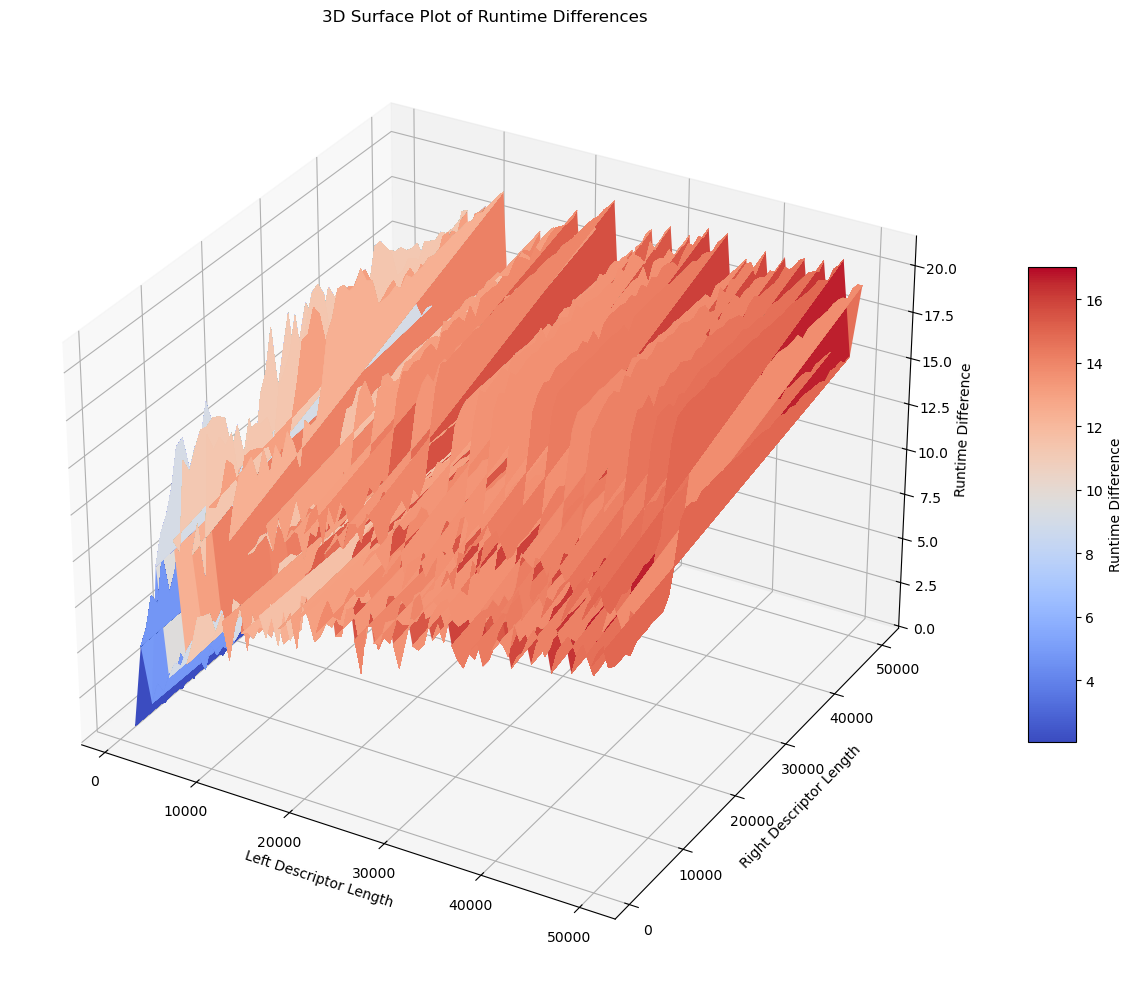

In [216]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot surface
surf = ax.plot_surface(X, Y, Z, cmap='coolwarm', edgecolor='none')

# Labels
ax.set_title("3D Surface Plot of Runtime Differences")
ax.set_xlabel("Left Descriptor Length")
ax.set_ylabel("Right Descriptor Length")
ax.set_zlabel("Runtime Difference")

# Add color bar
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='Runtime Difference')
plt.tight_layout()
plt.show()

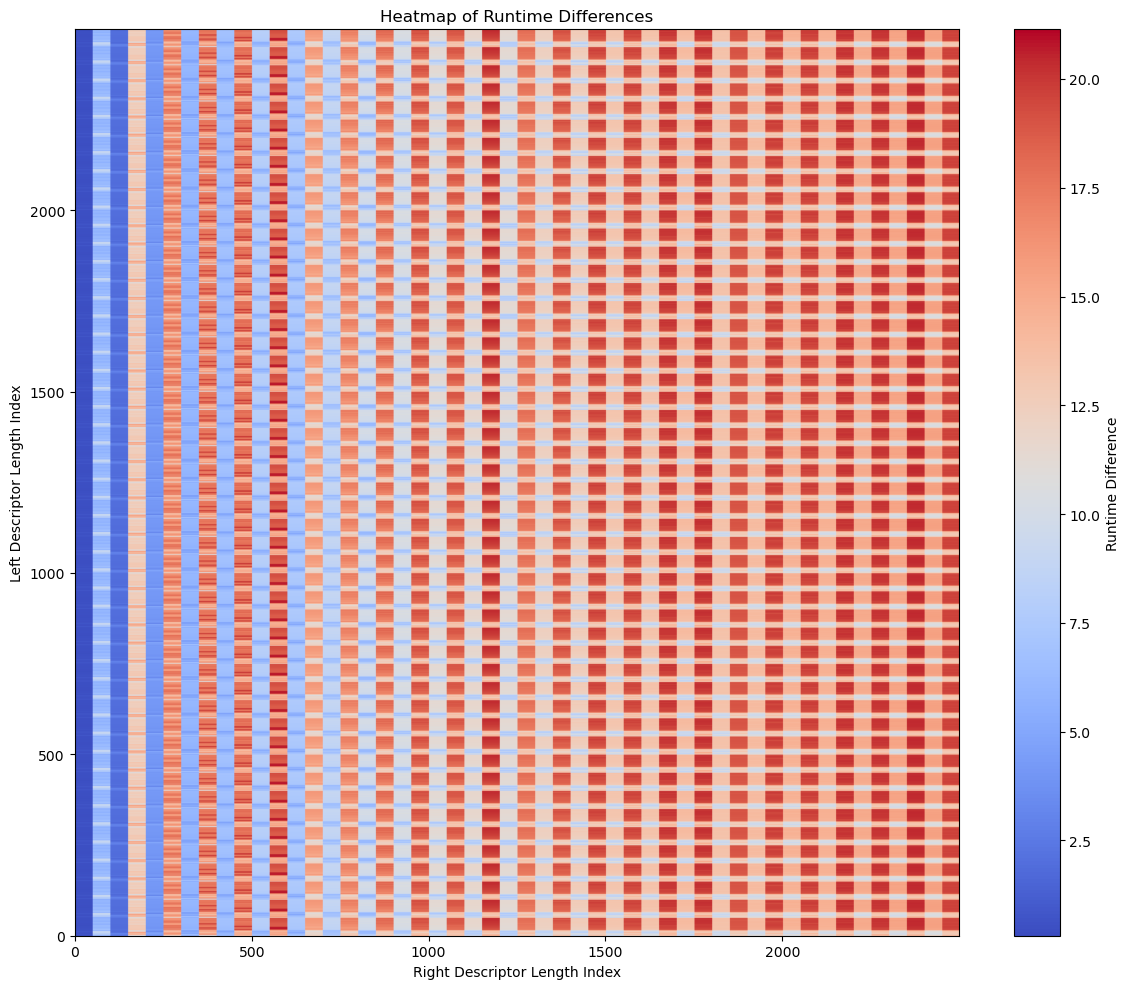

In [217]:
# import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
plt.imshow(Z, cmap='coolwarm', origin='lower', aspect='auto')

plt.colorbar(label='Runtime Difference')
plt.title("Heatmap of Runtime Differences")
plt.xlabel("Right Descriptor Length Index")
plt.ylabel("Left Descriptor Length Index")
plt.tight_layout()
plt.show()

In [ ]:
################################## CHAT STUFUS

In [ ]:
step = 25
diff_sampled = difference_matrix[::step, ::step]

plt.figure(figsize=(12, 10))
sns.heatmap(diff_sampled, cmap="coolwarm", center=0,
            cbar_kws={'label': 'Difference (Left - Right)'})
plt.title("Heatmap of Descriptor Differences (Downsampled)")
plt.xlabel("Right Descriptor Index (downsampled)")
plt.ylabel("Left Descriptor Index (downsampled)")
plt.tight_layout()
plt.show()

In [144]:
import numpy as np

# Simulate runtime or descriptor counts
np.random.seed(42)  # For reproducibility

# Let's assume these are runtimes in milliseconds
left_counts = np.random.normal(loc=100, scale=20, size=2500)   # mean=100ms
right_counts = np.random.normal(loc=95, scale=25, size=2500)   # mean=95ms


In [145]:
# Convert to arrays
left_array = np.array(left_counts)
right_array = np.array(right_counts)

# Create a 2500x2500 matrix of differences: left - right
difference_matrix = left_array[:, None] - right_array  # shape: (2500, 2500)

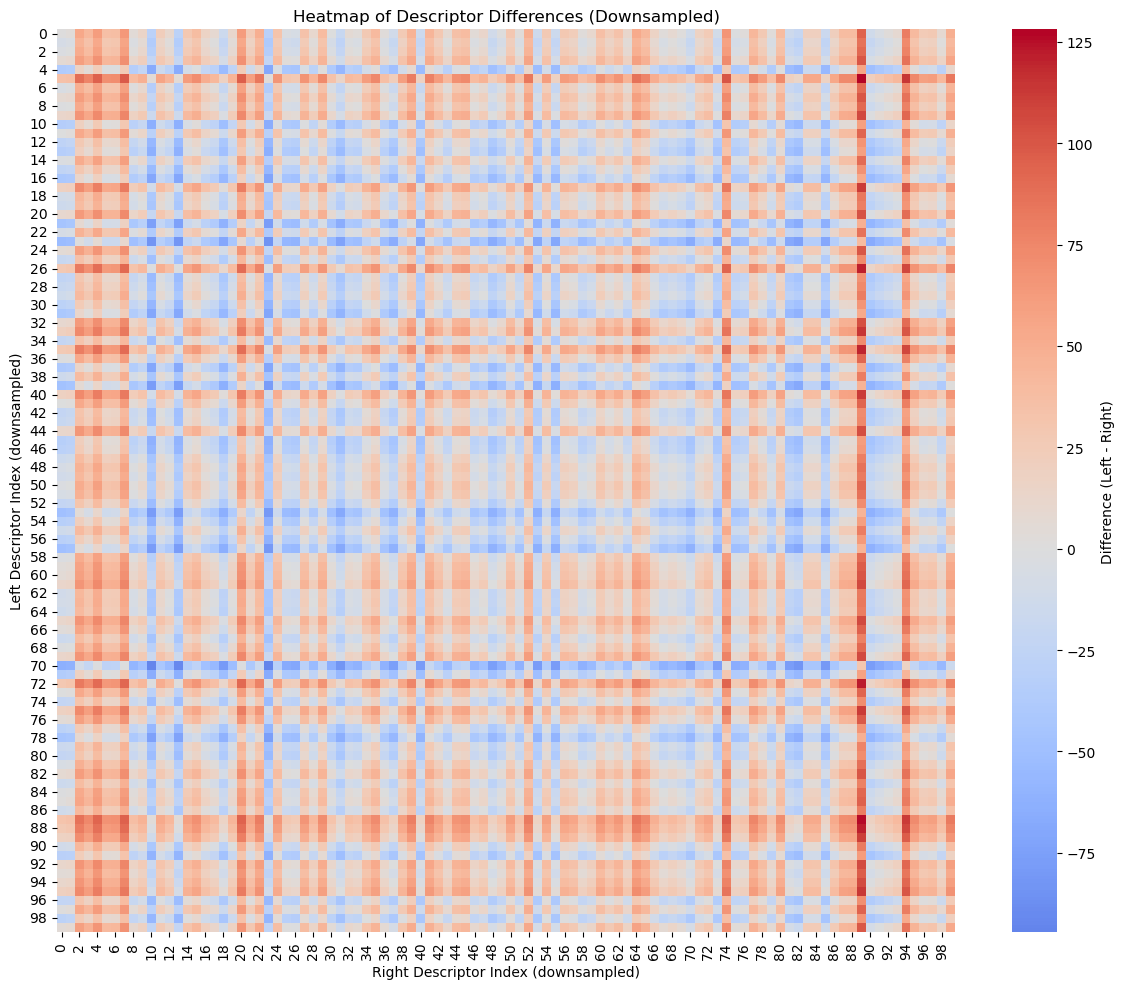

In [147]:
import seaborn as sns
import matplotlib.pyplot as plt

# Downsample for visualization (every 25th element = 100x100)
step = 25
diff_sampled 

plt.figure(figsize=(12, 10))
sns.heatmap(diff_sampled, cmap="coolwarm", center=0,
            cbar_kws={'label': 'Difference (Left - Right)'})
plt.title("Heatmap of Descriptor Differences (Downsampled)")
plt.xlabel("Right Descriptor Index (downsampled)")
plt.ylabel("Left Descriptor Index (downsampled)")
plt.tight_layout()
plt.show()

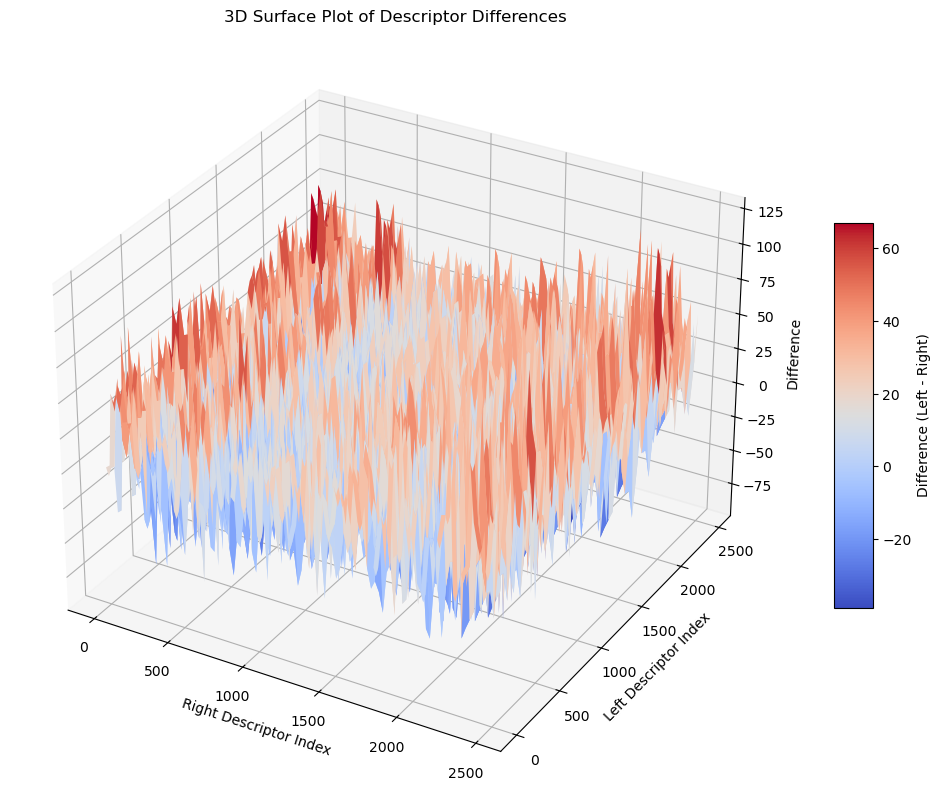

In [148]:
from mpl_toolkits.mplot3d import Axes3D

# Create grid indices
X = np.arange(0, 2500, step)
Y = np.arange(0, 2500, step)
X, Y = np.meshgrid(X, Y)

Z = diff_sampled  # Downsampled difference matrix

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# 3D surface plot
surf = ax.plot_surface(X, Y, Z, cmap='coolwarm', edgecolor='none')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='Difference (Left - Right)')

ax.set_title('3D Surface Plot of Descriptor Differences')
ax.set_xlabel('Right Descriptor Index')
ax.set_ylabel('Left Descriptor Index')
ax.set_zlabel('Difference')
plt.show()

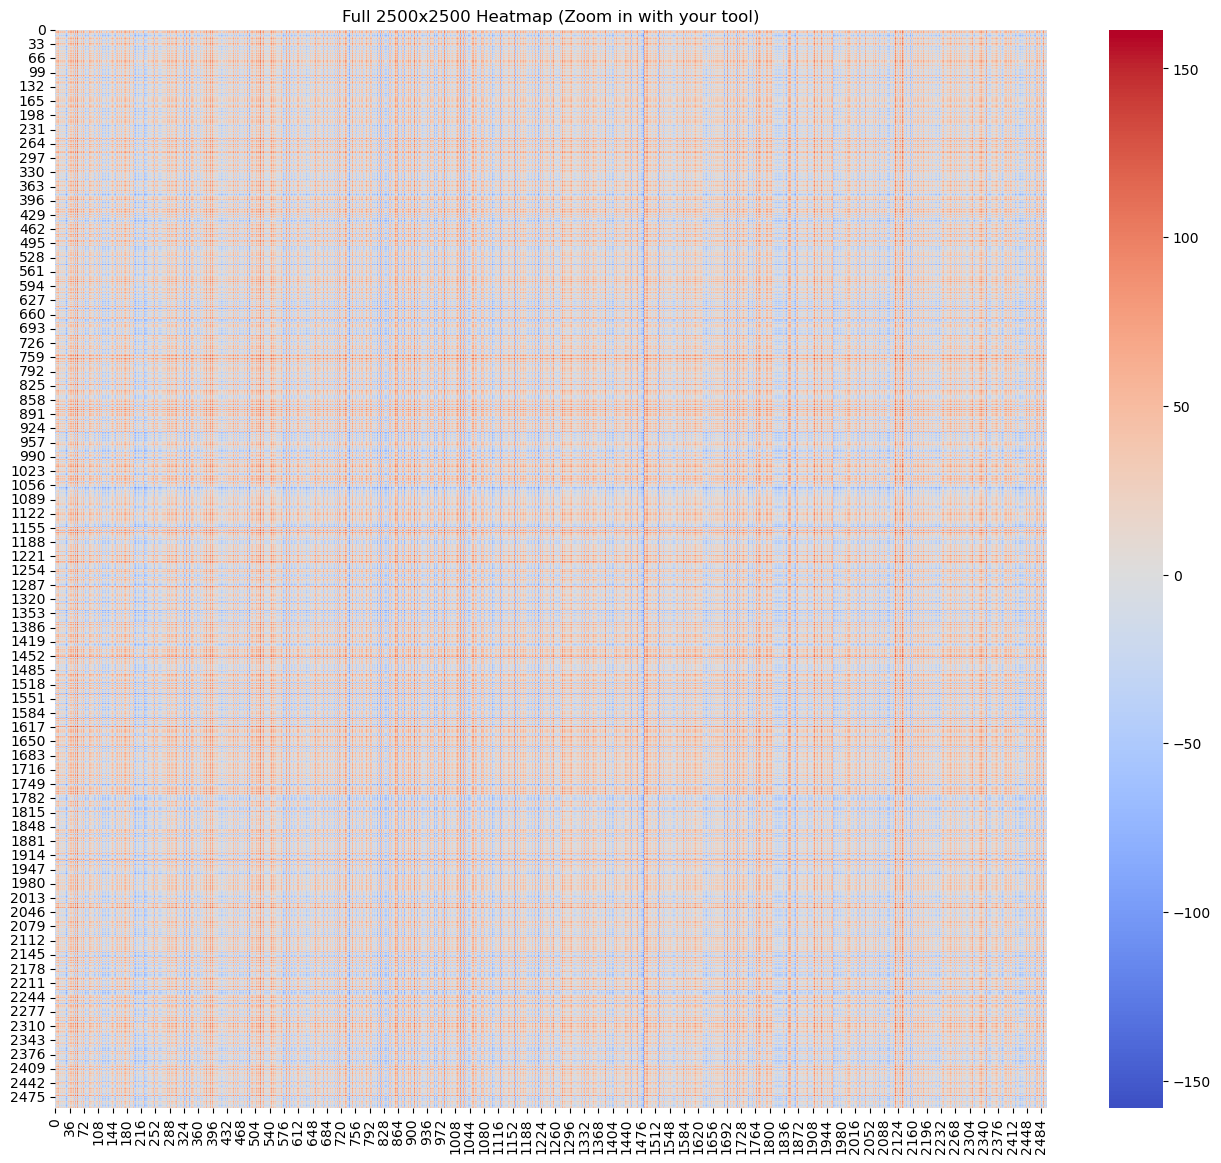

In [150]:
plt.figure(figsize=(16, 14))
sns.heatmap(difference_matrix, cmap="coolwarm", center=0)
plt.title("Full 2500x2500 Heatmap (Zoom in with your tool)")
plt.show()

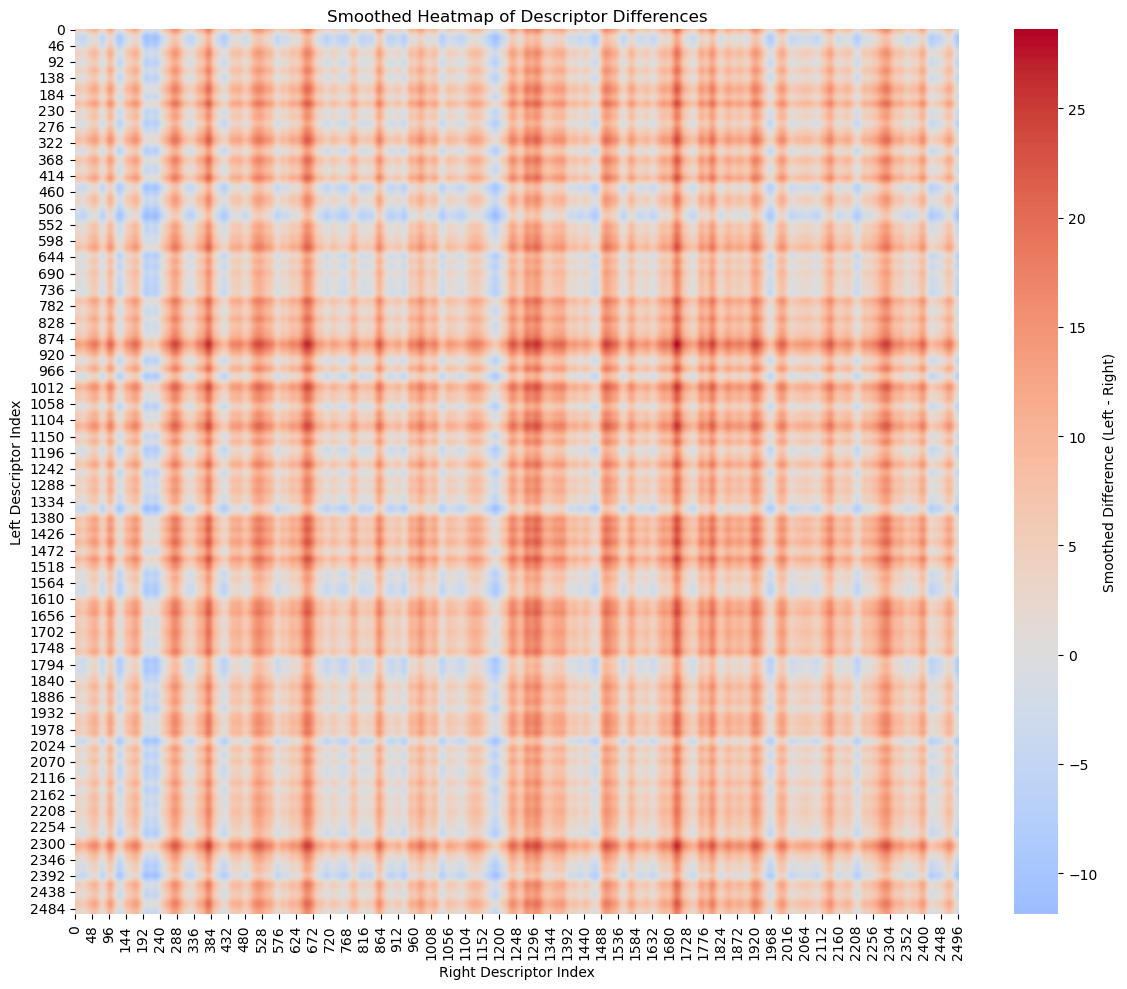

In [152]:
from scipy.ndimage import gaussian_filter

# Apply Gaussian smoothing
smoothed_matrix = gaussian_filter(difference_matrix, sigma=10)  # try sigma=5–20

# Plot smoothed heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(smoothed_matrix, cmap="coolwarm", center=0,
            cbar_kws={'label': 'Smoothed Difference (Left - Right)'})
plt.title("Smoothed Heatmap of Descriptor Differences")
plt.xlabel("Right Descriptor Index")
plt.ylabel("Left Descriptor Index")
plt.tight_layout()
plt.show()

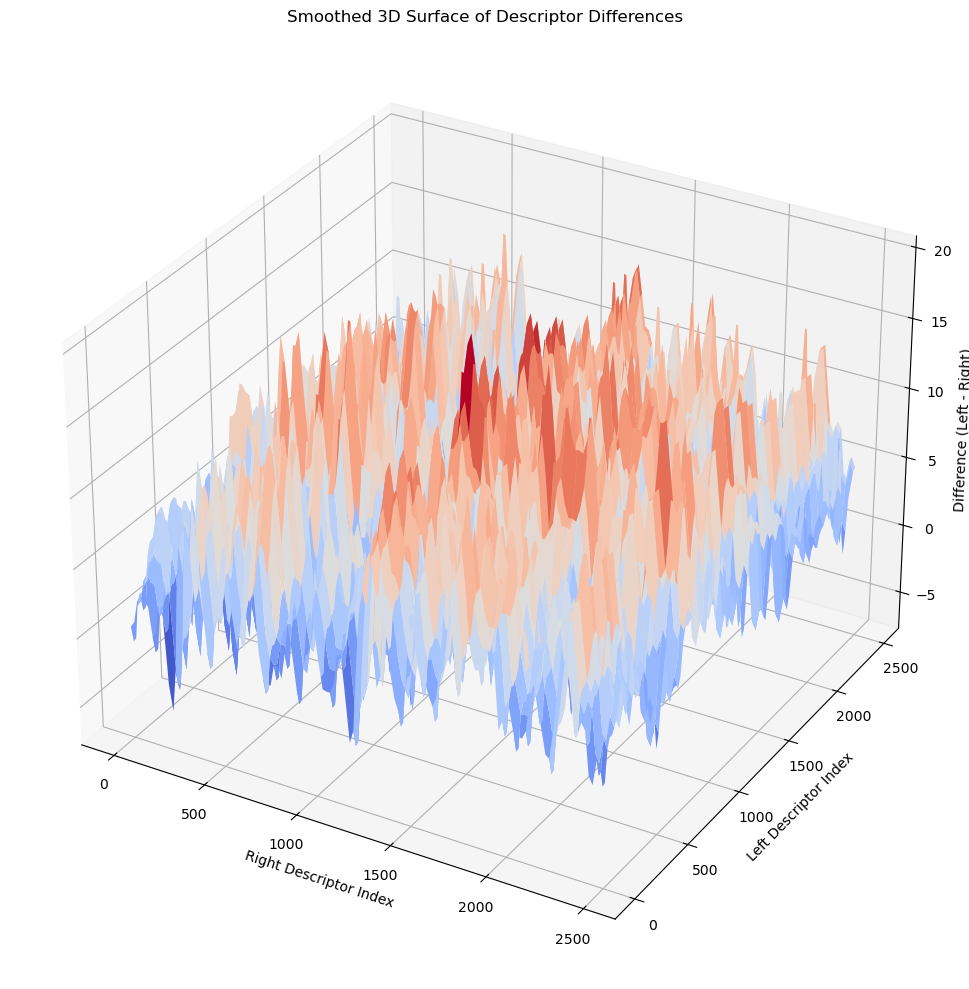

In [154]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from mpl_toolkits.mplot3d import Axes3D

# Dummy 2500-element runtime arrays
np.random.seed(42)
left_counts = np.random.normal(loc=100, scale=20, size=2500)
right_counts = np.random.normal(loc=95, scale=25, size=2500)

# Create full difference matrix
left_array = left_counts[:, None]
right_array = right_counts
difference_matrix = left_array - right_array  # shape: (2500, 2500)

# Apply Gaussian smoothing
sigma = 20  # adjust as needed
smoothed_matrix = gaussian_filter(difference_matrix, sigma=sigma)

# Prepare meshgrid for X and Y axes
x = np.arange(2500)
y = np.arange(2500)
X, Y = np.meshgrid(x, y)

# Create 3D surface plot
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# NOTE: Plotting full 2500x2500 may still be very slow
# You can smooth but also lightly downsample *after* smoothing for better speed
step = 20  # downsample lightly for rendering speed
ax.plot_surface(X[::step, ::step], Y[::step, ::step],
                smoothed_matrix[::step, ::step],
                cmap='coolwarm', edgecolor='none')

ax.set_title('Smoothed 3D Surface of Descriptor Differences')
ax.set_xlabel('Right Descriptor Index')
ax.set_ylabel('Left Descriptor Index')
ax.set_zlabel('Difference (Left - Right)')
plt.tight_layout()
plt.show()